In [63]:
import pandas as pd

# Load the raw datasets
plant1_gen_df = pd.read_csv("../data/raw/Plant_1_Generation_Data.csv")
plant1_weather_df = pd.read_csv("../data/raw/Plant_1_Weather_Sensor_Data.csv")

# Check the shapes (rows and columns) of each dataframe
print(f"Generation Data Shape: {plant1_gen_df.shape}")
print(f"Weather Data Shape:    {plant1_weather_df.shape}")

# Display the first 5 rows of the generation dataset
plant1_gen_df.head()

Generation Data Shape: (68778, 7)
Weather Data Shape:    (3182, 6)


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [49]:
plant1_weather_df.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [64]:
# Check the number of unique inverter IDs (SOURCE_KEY)
print(f"Number of Inverters: {plant1_gen_df['SOURCE_KEY'].nunique()}")

Number of Inverters: 22


In [65]:
# Check the dataframe structure, column data types, and non-null counts
plant1_gen_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  str    
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  str    
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), str(2)
memory usage: 5.7 MB


In [66]:
# Check the weather dataframe structure, column data types, and non-null counts
plant1_weather_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DATE_TIME            3182 non-null   str    
 1   PLANT_ID             3182 non-null   int64  
 2   SOURCE_KEY           3182 non-null   str    
 3   AMBIENT_TEMPERATURE  3182 non-null   float64
 4   MODULE_TEMPERATURE   3182 non-null   float64
 5   IRRADIATION          3182 non-null   float64
dtypes: float64(3), int64(1), str(2)
memory usage: 254.9 KB


In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the DATE_TIME column to datetime object format
plant1_gen_df['DATE_TIME'] = pd.to_datetime(plant1_gen_df['DATE_TIME'])

# Verify the start and end dates of the dataset period
print(f"Dataset Start Date: {plant1_gen_df['DATE_TIME'].min()}")
print(f"Dataset End Date:   {plant1_gen_df['DATE_TIME'].max()}")

Dataset Start Date: 2020-05-15 00:00:00
Dataset End Date:   2020-06-17 23:45:00


/var/folders/vd/3z40pz013hz0wjckp9xwk7hh0000gn/T/ipykernel_17624/1077442583.py:6: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  plant1_gen_df['DATE_TIME'] = pd.to_datetime(plant1_gen_df['DATE_TIME'])


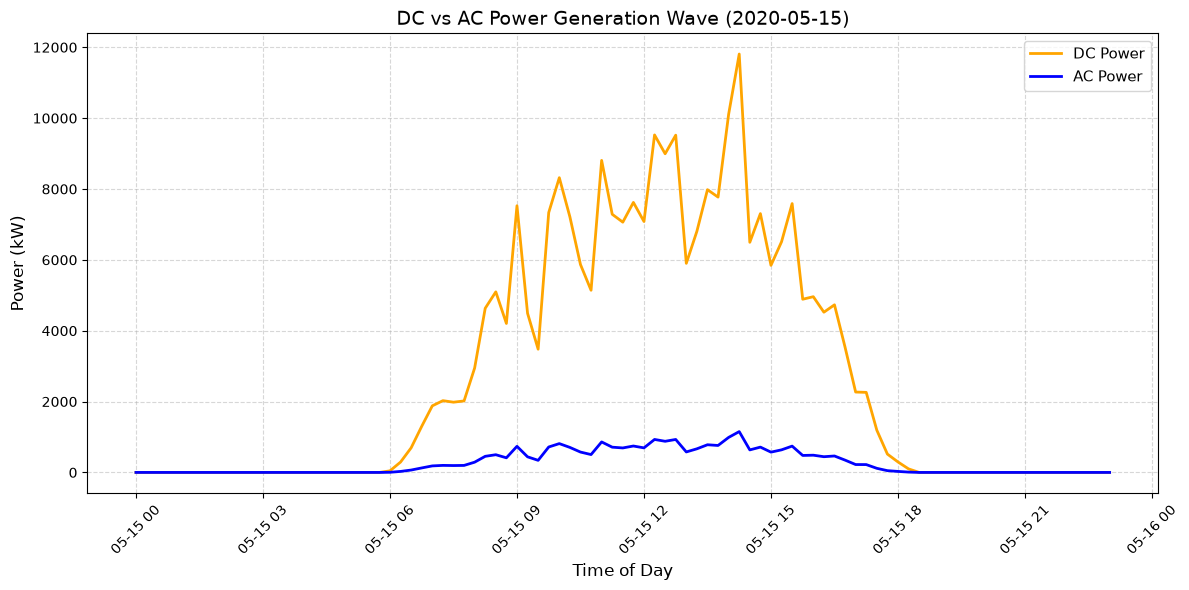

In [68]:
# 1. Specify the target date to analyze (Feel free to change the date for experimentation)
target_date = '2020-05-15'

# 2. Filter the dataset to include only the specified target date
day_df = plant1_gen_df[plant1_gen_df['DATE_TIME'].dt.date == pd.to_datetime(target_date).date()]

# 3. Calculate the average across all inverters since performance varies slightly per device
# (You can also filter by a specific SOURCE_KEY here if you want to inspect a single inverter)
hourly_avg = day_df.groupby('DATE_TIME')[['DC_POWER', 'AC_POWER']].mean().reset_index()

# 4. Plot the time-series comparative line chart
plt.figure(figsize=(12, 6))
# Updated labels to standard English to prevent any UserWarning font errors
plt.plot(hourly_avg['DATE_TIME'], hourly_avg['DC_POWER'], label='DC Power', color='orange', lw=2)
plt.plot(hourly_avg['DATE_TIME'], hourly_avg['AC_POWER'], label='AC Power', color='blue', lw=2)

plt.title(f"DC vs AC Power Generation Wave ({target_date})", fontsize=14)
plt.xlabel("Time of Day", fontsize=12)
plt.ylabel("Power (kW)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

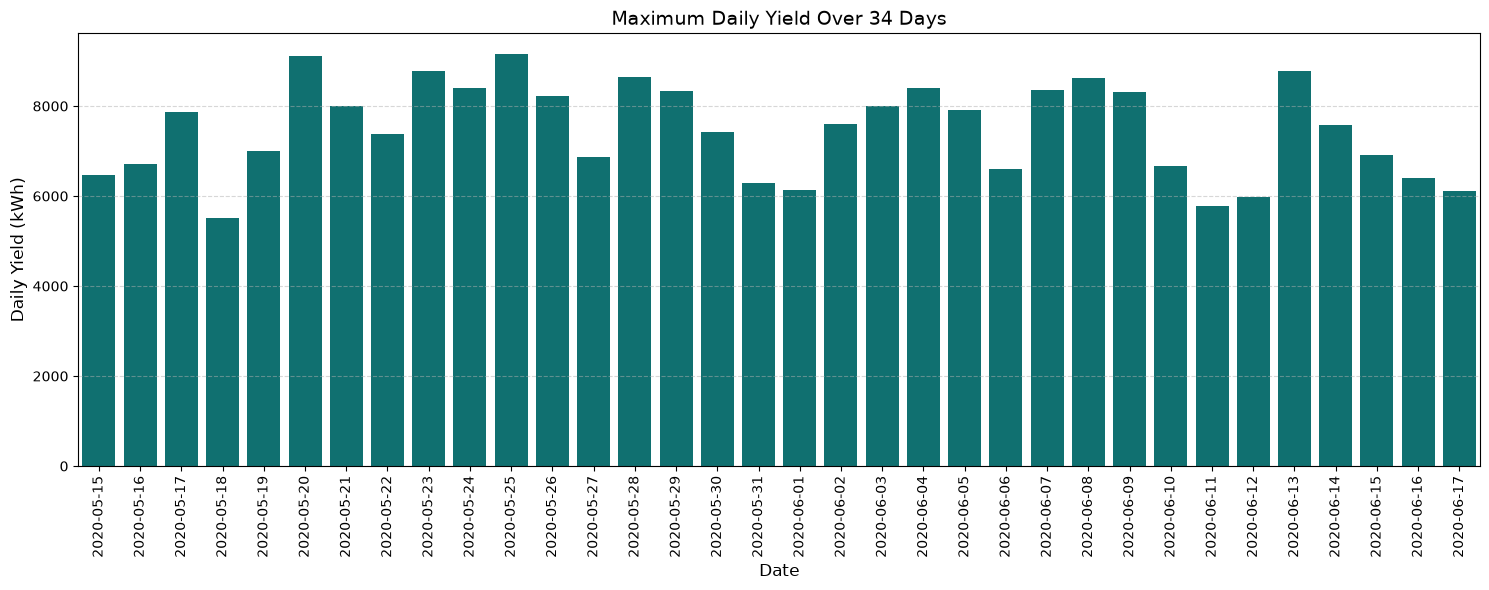

In [69]:
# 1. Create a temporary column extracting only the 'DATE' from DATE_TIME
plant1_gen_df['DATE'] = plant1_gen_df['DATE_TIME'].dt.date

# 2. Calculate the maximum DAILY_YIELD for each date (representing the final cumulative yield of the day)
daily_yield_max = plant1_gen_df.groupby('DATE')['DAILY_YIELD'].max().reset_index()

# 3. Plot the daily maximum yield as a bar chart
plt.figure(figsize=(15, 6))
sns.barplot(data=daily_yield_max, x='DATE', y='DAILY_YIELD', color='teal')

plt.title("Maximum Daily Yield Over 34 Days", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Daily Yield (kWh)", fontsize=12)
plt.xticks(rotation=90) # Rotate x-axis labels by 90 degrees for better readability
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

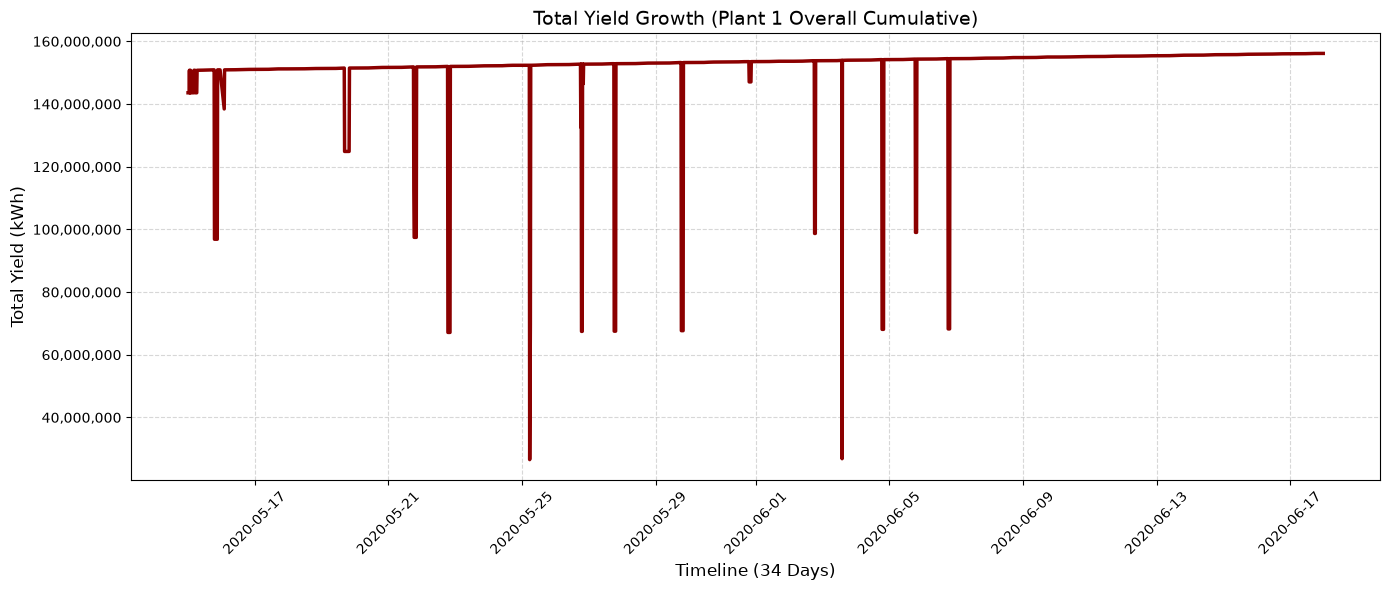

In [70]:
# 1. Calculate the total cumulative yield across all inverters for each timestamp
total_yield_trend = plant1_gen_df.groupby('DATE_TIME')['TOTAL_YIELD'].sum().reset_index()

# 2. Plot the time-series line chart
plt.figure(figsize=(14, 6))
plt.plot(total_yield_trend['DATE_TIME'], total_yield_trend['TOTAL_YIELD'], color='darkred', lw=2.5)

plt.title("Total Yield Growth (Plant 1 Overall Cumulative)", fontsize=14)
plt.xlabel("Timeline (34 Days)", fontsize=12)
plt.ylabel("Total Yield (kWh)", fontsize=12)

# Disable scientific notation (e.g., 1e7) on the y-axis for better readability
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [71]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert the DATE_TIME column to datetime object format (if not done already)
plant1_weather_df['DATE_TIME'] = pd.to_datetime(plant1_weather_df['DATE_TIME'])

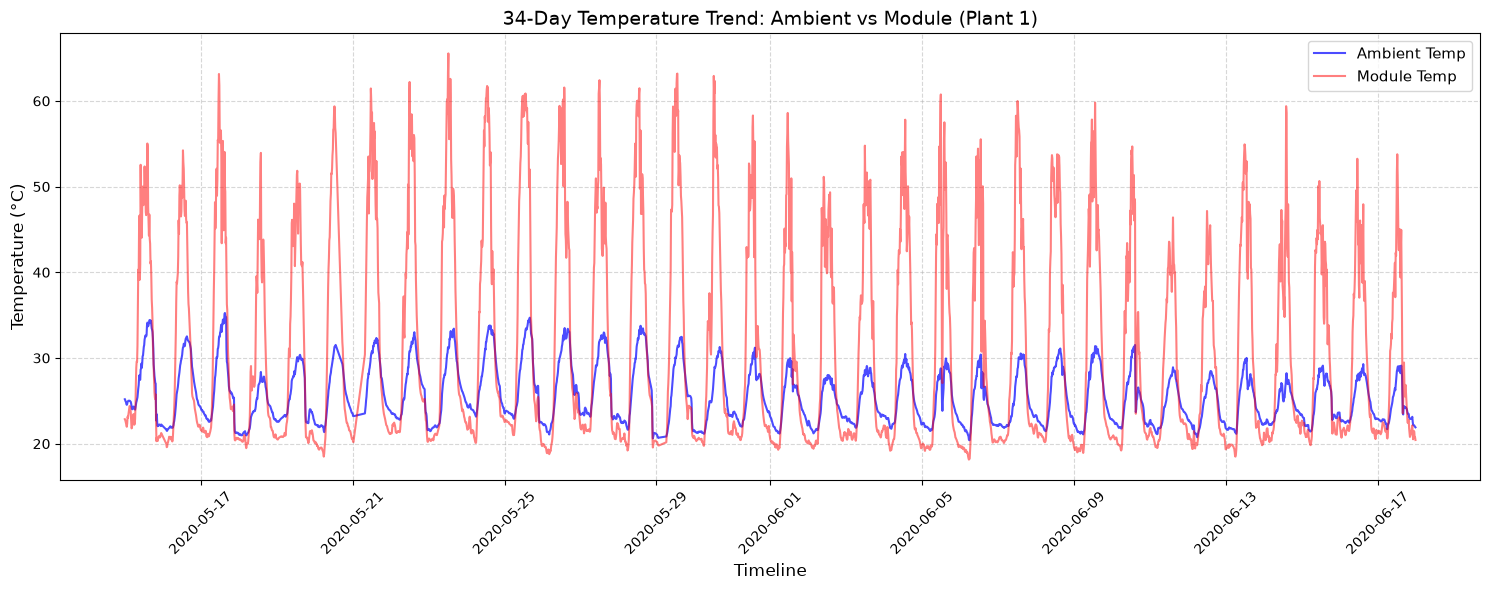

In [72]:
plt.figure(figsize=(15, 6))

# Plot the ambient and module temperatures overlapping each other
# Updated labels to standard English to prevent any UserWarning font errors
plt.plot(plant1_weather_df['DATE_TIME'], plant1_weather_df['AMBIENT_TEMPERATURE'], label='Ambient Temp', color='blue', alpha=0.7)
plt.plot(plant1_weather_df['DATE_TIME'], plant1_weather_df['MODULE_TEMPERATURE'], label='Module Temp', color='red', alpha=0.5)

plt.title("34-Day Temperature Trend: Ambient vs Module (Plant 1)", fontsize=14)
plt.xlabel("Timeline", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

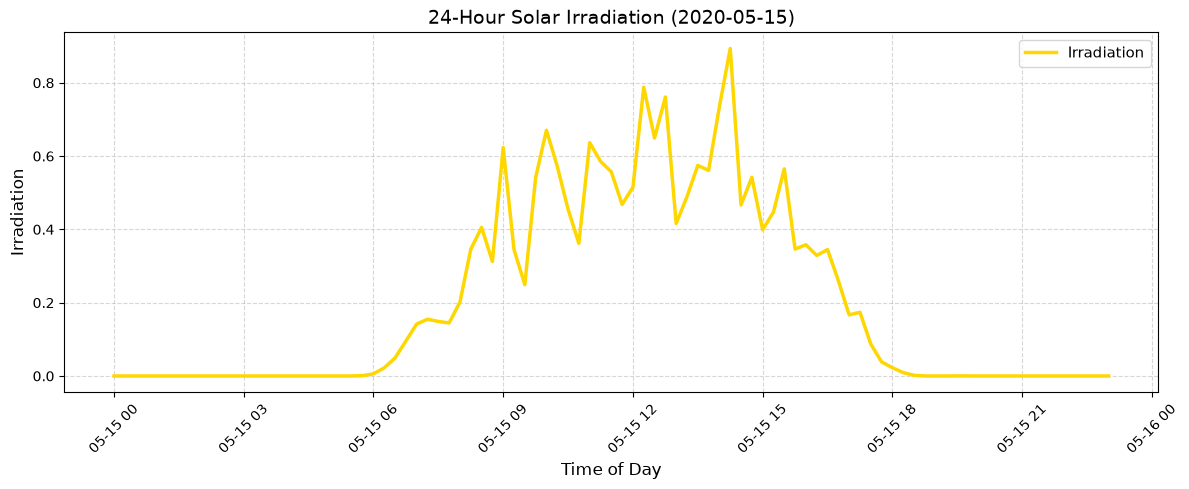

In [73]:
# 1. Specify the target date to analyze (Matching it with the generation data date is a best practice!)
target_date_weather = '2020-05-15'

# 2. Filter the dataset to include only the specified target date
day_weather_df = plant1_weather_df[plant1_weather_df['DATE_TIME'].dt.date == pd.to_datetime(target_date_weather).date()]

# 3. Plot the time-series line chart for solar irradiation
plt.figure(figsize=(12, 5))
# Updated label to standard English to prevent any UserWarning font errors
plt.plot(day_weather_df['DATE_TIME'], day_weather_df['IRRADIATION'], color='gold', lw=2.5, label='Irradiation')

plt.title(f"24-Hour Solar Irradiation ({target_date_weather})", fontsize=14)
plt.xlabel("Time of Day", fontsize=12)
plt.ylabel("Irradiation", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()